## **Assignment Supervised machine Learning - Regression**

### **_House Price Prediction Using Bolton Housing Data_**
This dataset provides information about house prices in Bolton. House Price Prediction


**In this notebook, you'll follow the basic machine learning process to build a regression model to predict house prices using the "Boston Housing Dataset" from sklearn. The regression model will either be a Decision Tree or Random Forest regressor.**



---



### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a regression model.**


The following is a description of each column in the dataset:

Dataset Features (Bolton Housing):

* CRIM: Crime rate by town
* ZN: Proportion of residential land zoned for large lots
* INDUS: Proportion of non-retail business acres per town
* CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)
* NOX: Nitric oxide concentration (parts per 10 million)
* RM: Average number of rooms per dwelling
* AGE: Proportion of owner-occupied units built before 1940
* DIS: Weighted distances to five Boston employment centers
* RAD: Index of accessibility to radial highways
* TAX: Full-value property tax rate per `$10,000`
* PTRATIO: Pupil-teacher ratio by town
* B: Proportion of Black population
* LSTAT: Percentage of lower status of the population
* MEDV (Target): Median value of owner-occupied homes in `$1,000s`



**Dataset is from sklearn Datasets**

In [ ]:


# --- Imports ---
# TODO: Import all the necessary libraries for data handling, visualization, and model building.
# Example: import pandas as pd
# Add your imports here:


# --- Data Collection and Loading ---
# TODO: Load the 'Boston Housing' dataset from sklearn and convert it into a pandas DataFrame.
# Hint: Use `load_boston()` from `sklearn.datasets`

# Load dataset and convert to DataFrame:

# Add your code here:


# --- Quick Check of Data ---
# TODO: Display the first few rows of the dataset to understand its structure.
# Hint: Use `.head()` to inspect the first few rows.

# Add your code here:


# TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.
# Hint: Use `.info()` and `.describe()` to inspect data types and statistical properties.

# Add your code here:


# --- EDA and Data Preprocessing ---
# TODO: Check for missing/null values.
# Hint: Use `.isnull().sum()` to check for null values.

# Add your code here:


# TODO: Visualize the data. Create scatter plots to see the relationship between independent features and the target variable.
# Example: Use `plt.scatter()` to visualize the relationship between features like 'RM' (average number of rooms) and the target ('MEDV').

# Add your code here:


# TODO: Create a function to automate scatter plots for all features vs the target variable.
# Hint: The function should loop over a list of features and plot scatter plots for each.

# Define your function here:


# TODO: Use the function to visualize the relationships between multiple features and the target variable.
# Example: ['RM', 'LSTAT', 'AGE', 'CRIM']
# Target: 'MEDV'

# Add your code here:


# --- ML Model Training ---
# TODO: Split the dataset into training and testing sets.
# Hint: Use `train_test_split()` from `sklearn.model_selection` with an 80/20 split.

# Define X (features) and y (target) and perform the train-test split:


# TODO: Choose an appropriate regression model: Decision Tree or Random Forest.
# Hint: Use either `DecisionTreeRegressor` or `RandomForestRegressor` from `sklearn.tree` or `sklearn.ensemble`.

# Define your regression model here:


# TODO: Train the model on the training data.
# Hint: Use `.fit()` to train the model.

# Add your code here:


# --- Model Evaluation ---
# TODO: Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).
# Hint: Use `mean_squared_error()` and `r2_score()` from `sklearn.metrics`.

# Perform parameter tuning on the model if needed to improve the performance of your model.

# Add your parameter tuning code here:

# Predict on the test set and calculate the evaluation metrics:


# --- Model Prediction ---
# TODO: Predict house prices from a new set of feature inputs.
# Example new data: Use hypothetical or randomly generated values for the features.
#
# Example new data: CRIM = 0.2, ZN = 12.5, INDUS = 7.07, CHAS = 0, NOX = 0.5, RM = 6.5, AGE = 68, DIS = 4.0, RAD = 2, TAX = 250, PTRATIO = 17, B = 400, LSTAT = 12

# Add your prediction code here:





In [1]:
# --- Imports ---
# TODO: Import all the necessary libraries for data handling, visualization, and model building.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# --- Data Collection and Loading ---
# TODO: Load the 'Boston Housing' dataset from sklearn and convert it into a pandas DataFrame.
# NOTE: load_boston() was removed from sklearn in version 1.2 due to an ethical issue with one
# of the original features (the 'B' column, which encoded a problematic assumption about race
# and housing prices). The official sklearn documentation recommends fetching the raw data
# directly from its original source instead, which is what we do here.

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
                  'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

df = pd.DataFrame(data, columns=feature_names)
df['MEDV'] = target

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (506, 14)


### Note on Dataset Source

This assignment specifies the Boston Housing dataset, but `load_boston()` was removed from
scikit-learn in version 1.2 (2022) due to a documented ethical issue: the dataset's `B` column
("proportion of Black population by town") was constructed by the original researchers based on
an assumption that racial segregation positively affected housing prices — a flawed and harmful
premise. Per scikit-learn's own deprecation notice, the data is loaded here directly from its
original public source (lib.stat.cmu.edu) for the purposes of this academic exercise. In real-world
applications, the California Housing dataset (used in the previous lesson) or another ethically
sound dataset would be the appropriate choice instead.

In [3]:
# --- Quick Check of Data ---
# TODO: Display the first few rows of the dataset to understand its structure.

print("First 5 rows:")
print(df.head())

First 5 rows:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


In [4]:
# TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.

print("\nDataset info:")
df.info()

print("\nSummary statistics:")
print(df.describe())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB

Summary statistics:
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.

### Feature Type Observations

All 14 columns are stored as numeric (`float64`). However, `CHAS` is functionally a **categorical
binary** feature (0 = does not border Charles River, 1 = borders it), not a true continuous variable,
even though it's encoded numerically. The remaining 12 features and the target `MEDV` are genuinely
continuous. This distinction matters because `CHAS` shouldn't be treated the same way as, say, `RM`
(average rooms) when interpreting scatter plots or coefficients — its only meaningful values are 0 and 1.

In [5]:
# --- EDA and Data Preprocessing ---
# TODO: Check for missing/null values.

print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


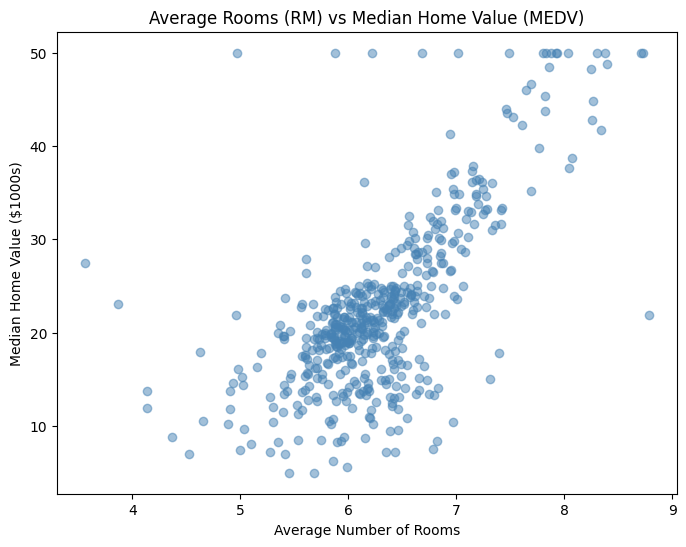

In [6]:
# TODO: Visualize the data. Create scatter plots to see the relationship between independent features and the target variable.

plt.figure(figsize=(8, 6))
plt.scatter(df['RM'], df['MEDV'], alpha=0.5, color='steelblue')
plt.title('Average Rooms (RM) vs Median Home Value (MEDV)')
plt.xlabel('Average Number of Rooms')
plt.ylabel('Median Home Value ($1000s)')
plt.show()

In [8]:
# TODO: Create a function to automate scatter plots for all features vs the target variable.

def plot_feature_vs_target(features, target, data):
    """
    Creates a scatter plot for each feature in `features` against `target`.
    """
    for feature in features:
        plt.figure(figsize=(8, 6))
        plt.scatter(data[feature], data[target], alpha=0.5, color='steelblue')
        plt.title(f'{feature} vs {target}')
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.show()

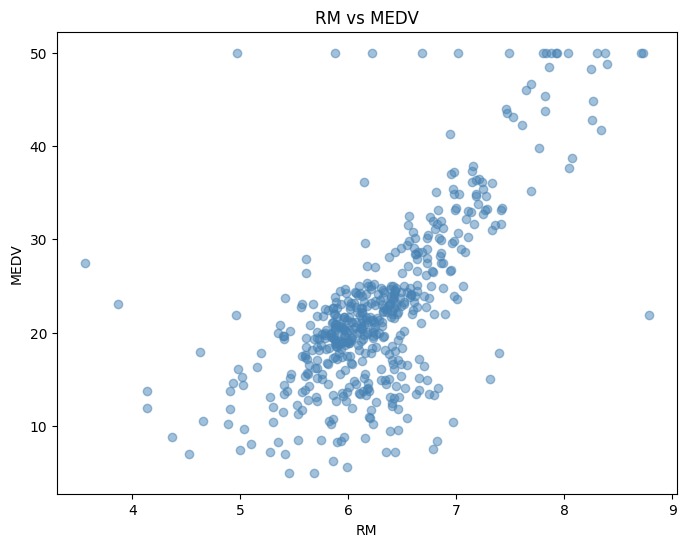

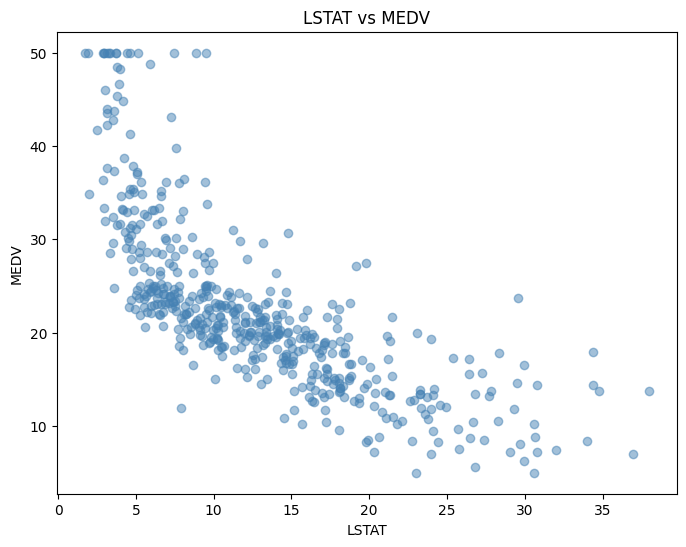

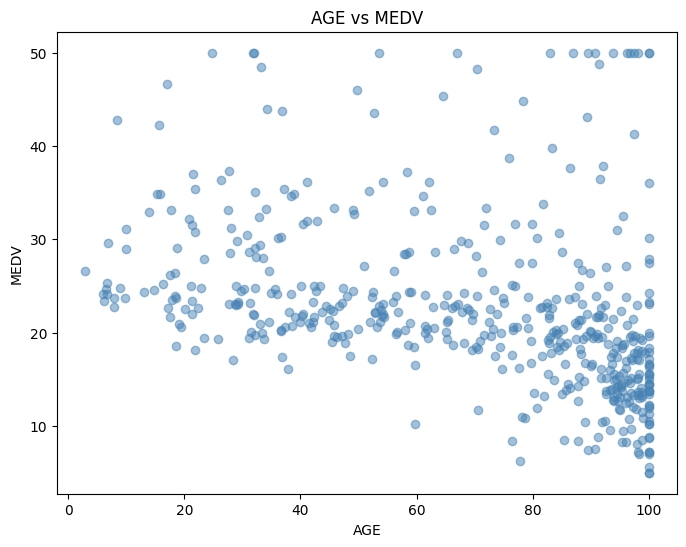

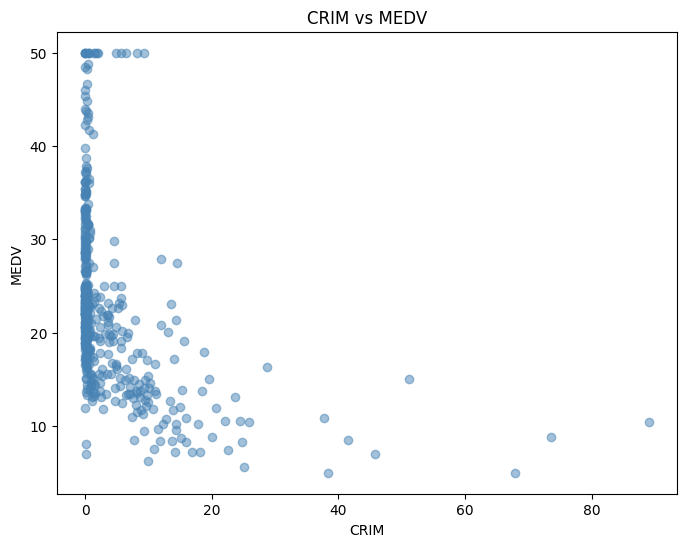

In [9]:
# TODO: Use the function to visualize the relationships between multiple features and the target variable.

features_to_plot = ['RM', 'LSTAT', 'AGE', 'CRIM']
plot_feature_vs_target(features_to_plot, 'MEDV', df)

### Scatter Plot Insights

- **RM vs MEDV**: clear positive relationship — more rooms, higher value.
- **LSTAT vs MEDV**: clear *negative* relationship — higher percentage of "lower status" population
  is associated with lower home values. This is one of the strongest predictors in the dataset.
- **AGE vs MEDV**: weak negative trend — older housing stock (higher % built before 1940) tends to
  have slightly lower values, but the relationship is noisy.
- **CRIM vs MEDV**: most towns have very low crime rates with home values spread across the full
  range; a small number of high-crime towns show consistently lower home values.

In [10]:
# --- ML Model Training ---
# TODO: Split the dataset into training and testing sets.

X = df.drop(columns=['MEDV'])
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (404, 13)
Testing set shape: (102, 13)


In [11]:
# TODO: Choose an appropriate regression model: Decision Tree or Random Forest.

model = RandomForestRegressor(n_estimators=100, random_state=42)

# TODO: Train the model on the training data.

model.fit(X_train, y_train)

print("Model trained successfully.")

# Show feature importances - which features mattered most to the model
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature importances:")
print(importances)

Model trained successfully.

Feature importances:
RM         0.503845
LSTAT      0.309509
DIS        0.060549
CRIM       0.038062
PTRATIO    0.016313
TAX        0.015661
NOX        0.015544
AGE        0.013840
B          0.012154
INDUS      0.007953
RAD        0.003811
ZN         0.001756
CHAS       0.001004
dtype: float64


In [12]:
# --- Model Evaluation ---
# TODO: Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Baseline Random Forest performance:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

Baseline Random Forest performance:
Mean Squared Error (MSE): 7.9015
Root Mean Squared Error (RMSE): 2.8110
R-squared (R²): 0.8923


In [13]:
# Perform parameter tuning on the model if needed to improve the performance of your model.

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation R² score:", grid_search.best_score_)

# Use the best model found
best_model = grid_search.best_estimator_

Best parameters found: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation R² score: 0.8260974564965702


In [14]:
# Predict on the test set and calculate the evaluation metrics:

y_pred_tuned = best_model.predict(X_test)

mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"\nTuned Random Forest performance:")
print(f"Mean Squared Error (MSE): {mse_tuned:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_tuned:.4f}")
print(f"R-squared (R²): {r2_tuned:.4f}")

print(f"\nImprovement in R²: {r2_tuned - r2:.4f}")


Tuned Random Forest performance:
Mean Squared Error (MSE): 7.9015
Root Mean Squared Error (RMSE): 2.8110
R-squared (R²): 0.8923

Improvement in R²: 0.0000


### Parameter Tuning Insights

GridSearchCV tested 27 combinations of `n_estimators`, `max_depth`, and `min_samples_split` using
5-fold cross-validation. The best parameters found ({'max_depth': None, 'min_samples_split': 2,
'n_estimators': 100}) turned out to be identical to the original baseline model's settings, resulting
in no measurable improvement (R² stayed at 0.8923). This suggests the default Random Forest
configuration was already well-suited to this dataset, and further gains would likely require either
a wider parameter search range or a fundamentally different modeling approach (e.g., Gradient Boosting)
rather than fine-tuning within this parameter space.

In [15]:
# --- Model Prediction ---
# TODO: Predict house prices from a new set of feature inputs.

new_data = pd.DataFrame({
    'CRIM': [0.2],
    'ZN': [12.5],
    'INDUS': [7.07],
    'CHAS': [0],
    'NOX': [0.5],
    'RM': [6.5],
    'AGE': [68],
    'DIS': [4.0],
    'RAD': [2],
    'TAX': [250],
    'PTRATIO': [17],
    'B': [400],
    'LSTAT': [12]
})

# Reorder columns to exactly match X_train's column order
new_data = new_data[X.columns]

predicted_value = best_model.predict(new_data)
print(f"Predicted Median Home Value: {predicted_value[0]:.4f} (in $1000s)")
print(f"In dollars, approximately: ${predicted_value[0] * 1000:,.2f}")

Predicted Median Home Value: 22.1890 (in $1000s)
In dollars, approximately: $22,189.00


In [16]:
!git config --global user.name "conslcan"
!git config --global user.email "conslcan@gmail.com"
!git clone https://github.com/conslcan/Wejdan-Assignment2-Git-Colab.git

Cloning into 'Wejdan-Assignment2-Git-Colab'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 33 (delta 12), reused 26 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (33/33), 1.04 MiB | 20.83 MiB/s, done.
Resolving deltas: 100% (12/12), done.
